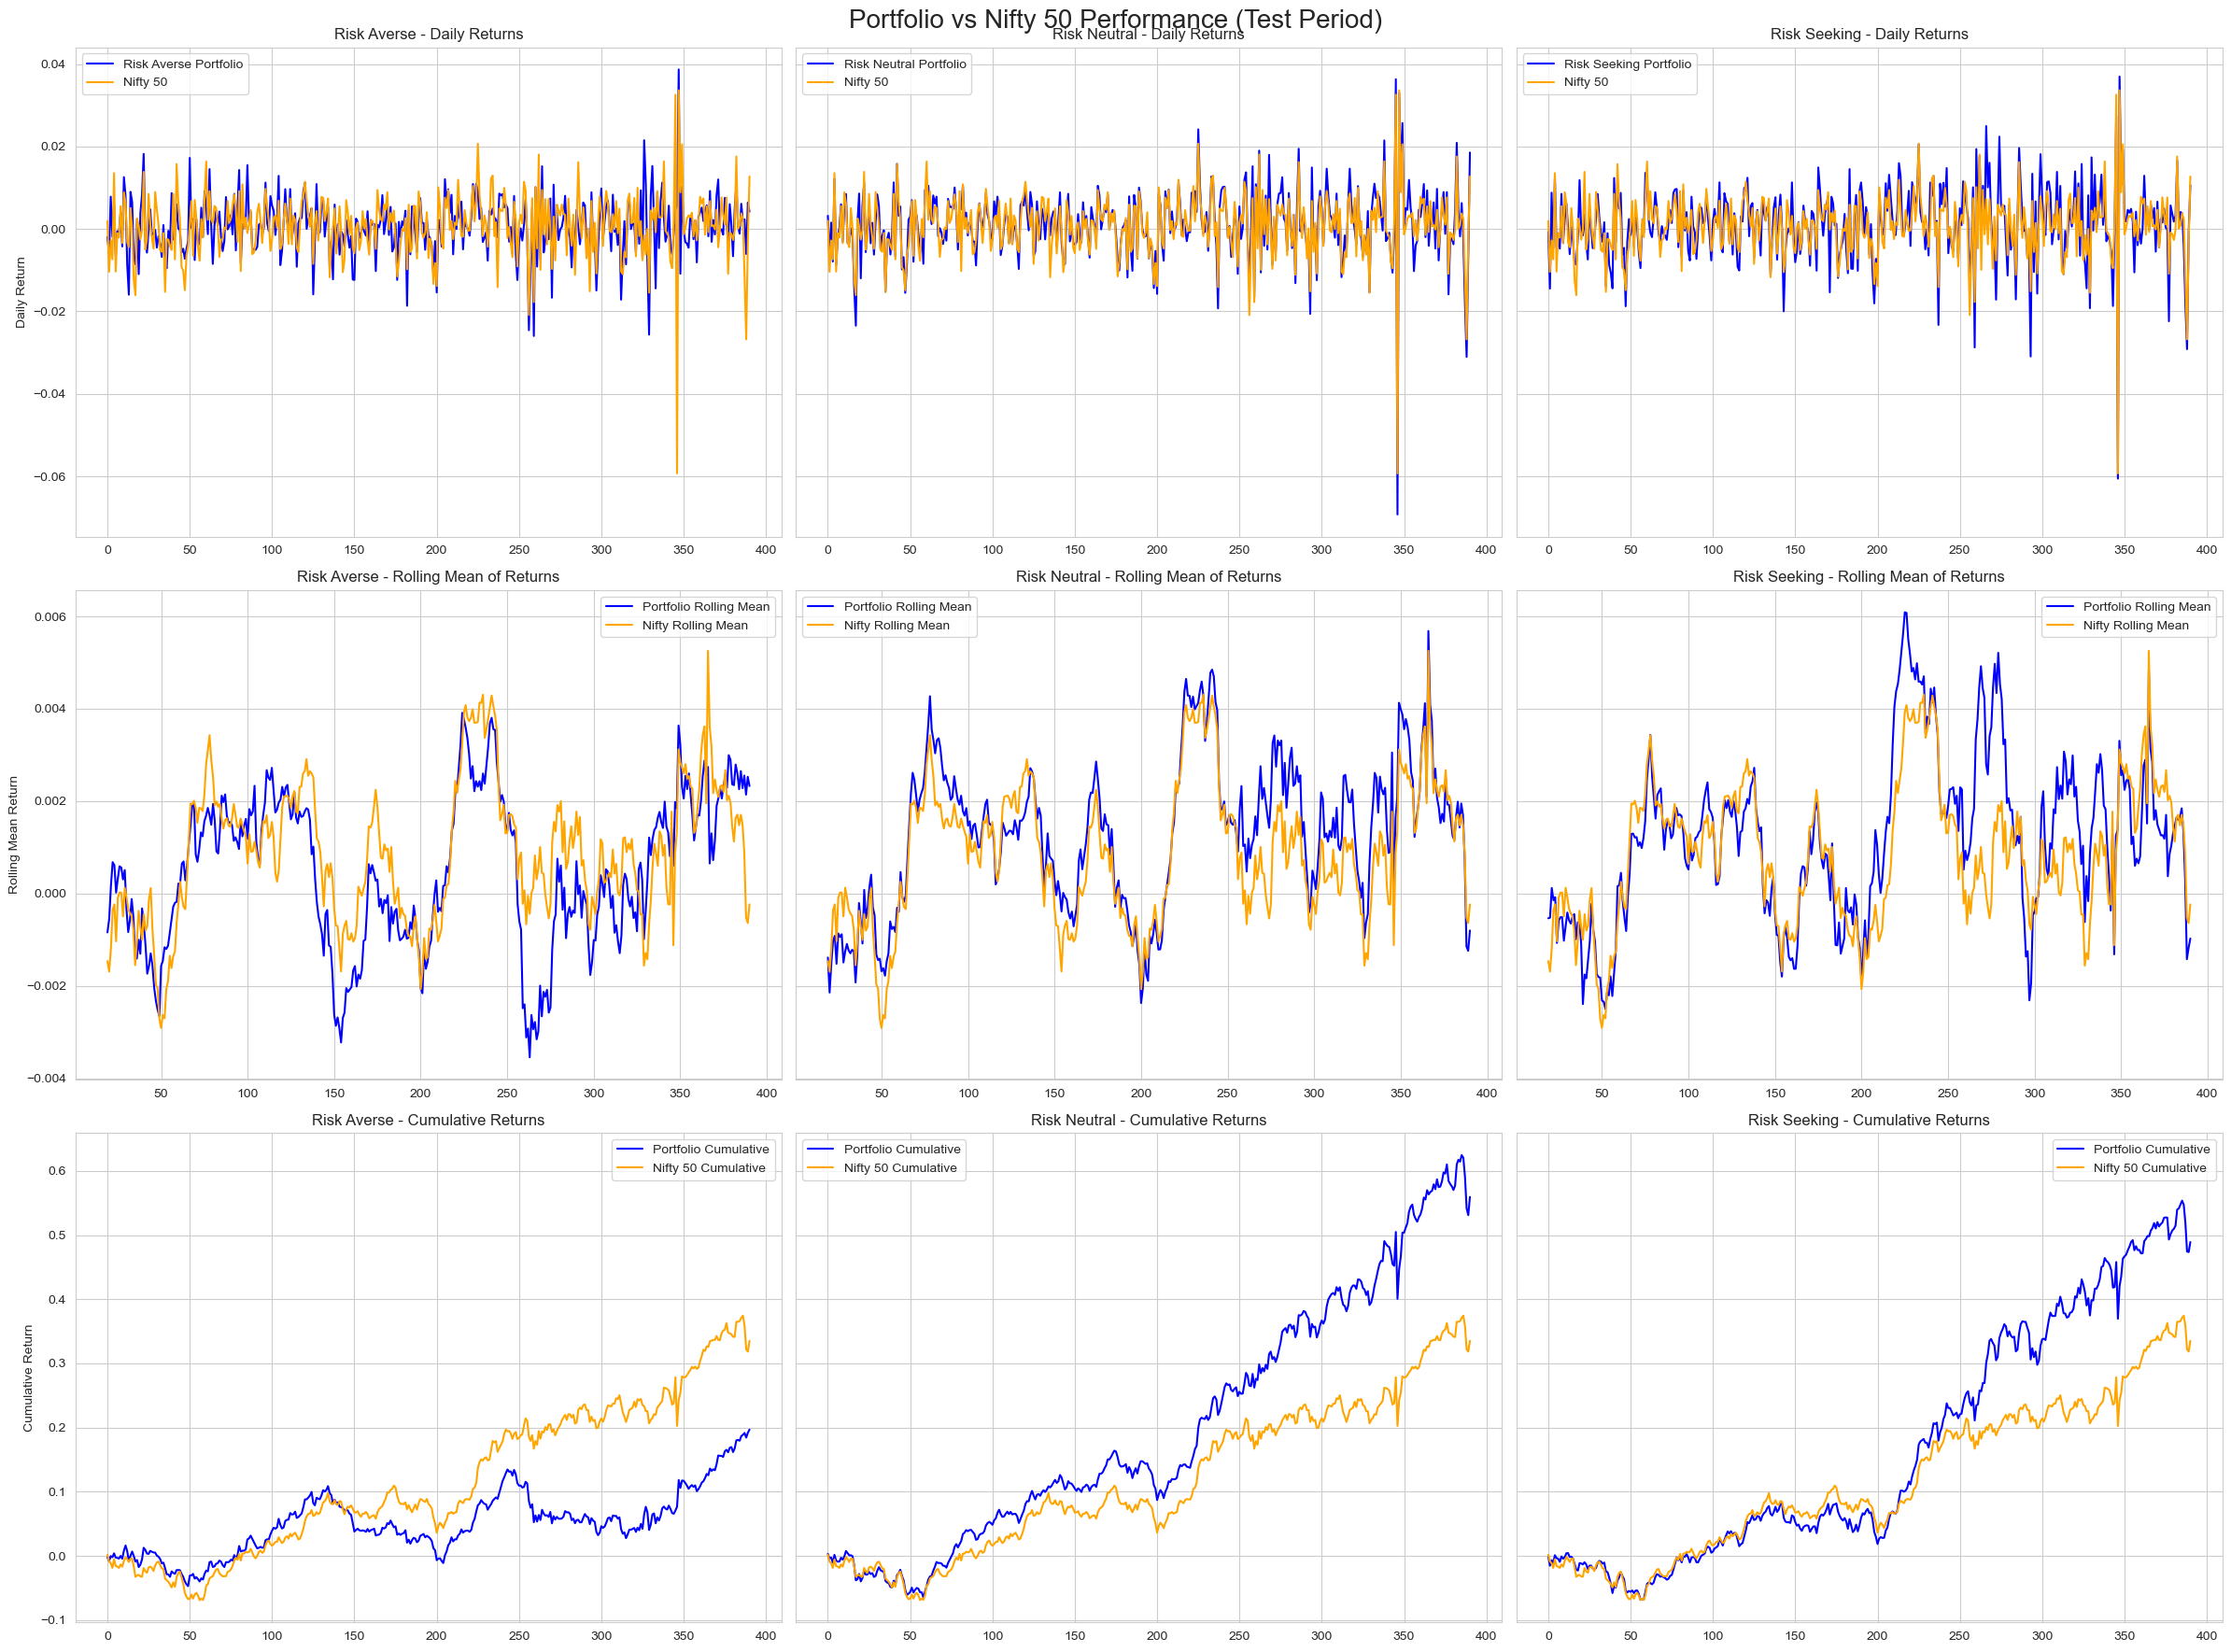

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

def compute_test_cumulative_returns(test_data_folder, test_weights_file, nifty_test_data_file, category, feature_column='Close', transaction_cost=0.01, risk_free_rate=0.05, extreme_threshold=1000):
    categorized_results_folder = "/Users/pranayvij/MTP-Work/categorized_results/"
    category_file = os.path.join(categorized_results_folder, f"{category}_stocks.csv")
    category_df = pd.read_csv(category_file)
    tickers = category_df['Ticker'].tolist()

    stock_data_files = [os.path.join(test_data_folder, f"{ticker}_test.csv") for ticker in tickers if os.path.exists(os.path.join(test_data_folder, f"{ticker}_test.csv"))]
    if not stock_data_files:
        print(f"⚠️ No stock data found for {category}. Skipping...")
        return None, None, None, None

    portfolio_weights = pd.read_csv(test_weights_file, header=None)
    if portfolio_weights.shape[1] != len(stock_data_files):
        print(f"⚠️ Weight/Data mismatch for {category}. Skipping...")
        return None, None, None, None

    stock_returns_list = [pd.read_csv(file)[feature_column].pct_change().dropna().values for file in stock_data_files]
    nifty_returns = pd.read_csv(nifty_test_data_file)[feature_column].pct_change().dropna().values

    min_length = min(min(len(r) for r in stock_returns_list), len(portfolio_weights), len(nifty_returns))
    stock_returns = np.array([r[:min_length] for r in stock_returns_list]).T
    portfolio_weights = portfolio_weights.values[:min_length, :]
    nifty_returns = nifty_returns[:min_length]

    mask = (np.abs(portfolio_weights) > extreme_threshold).any(axis=1)
    stock_returns = stock_returns[~mask]
    portfolio_weights = portfolio_weights[~mask]
    nifty_returns = nifty_returns[~mask]

    portfolio_weights = portfolio_weights / np.clip(portfolio_weights.sum(axis=1, keepdims=True), 1e-6, None)
    portfolio_returns = np.sum(stock_returns * portfolio_weights, axis=1)

    for i in range(1, len(portfolio_returns)):
        rebalance_cost = transaction_cost * np.sum(np.abs(portfolio_weights[i] - portfolio_weights[i-1]))
        portfolio_returns[i] -= rebalance_cost

    portfolio_cum_returns = np.cumprod(1 + portfolio_returns) - 1
    nifty_cum_returns = np.cumprod(1 + nifty_returns) - 1
    rolling_portfolio_returns = pd.Series(portfolio_returns).rolling(window=20).mean()
    rolling_nifty_returns = pd.Series(nifty_returns).rolling(window=20).mean()

    return portfolio_returns, nifty_returns, rolling_portfolio_returns, rolling_nifty_returns, portfolio_cum_returns, nifty_cum_returns

# Paths
test_data_folder = "/Users/pranayvij/MTP-Work/test_data"
nifty_test_data_file = "/Users/pranayvij/MTP-Work/^NSEI_test.csv"
result_folder = "/Users/pranayvij/MTP-Work/results"
portfolio_categories = ["risk_averse", "risk_neutral", "risk_seeking"]

# Store returns
portfolio_returns_dict = {}
nifty_returns_dict = {}
rolling_portfolio_returns_dict = {}
rolling_nifty_returns_dict = {}
portfolio_cum_returns_dict = {}
nifty_cum_returns_dict = {}

for category in portfolio_categories:
    test_weights_file = os.path.join(result_folder, f"test_portfolio_weights_{category}.csv")
    if os.path.exists(test_weights_file):
        p_ret, n_ret, roll_p, roll_n, p_cum, n_cum = compute_test_cumulative_returns(
            test_data_folder, test_weights_file, nifty_test_data_file, category
        )
        if p_ret is not None:
            portfolio_returns_dict[category] = p_ret
            nifty_returns_dict[category] = n_ret
            rolling_portfolio_returns_dict[category] = roll_p
            rolling_nifty_returns_dict[category] = roll_n
            portfolio_cum_returns_dict[category] = p_cum
            nifty_cum_returns_dict[category] = n_cum
    else:
        print(f"⚠️ Test weights missing for {category}. Skipping...")

# Create 3x3 grid plot
sns.set_style("whitegrid")
fig, axes = plt.subplots(3, 3, figsize=(24, 18), sharey='row')

for idx, category in enumerate(portfolio_categories):
    # Daily returns
    axes[0, idx].plot(portfolio_returns_dict[category], label=f"{category.replace('_', ' ').title()} Portfolio", color='blue')
    axes[0, idx].plot(nifty_returns_dict[category], label="Nifty 50", color='orange')
    axes[0, idx].set_title(f"{category.replace('_', ' ').title()} - Daily Returns")
    axes[0, idx].legend()

    # Rolling mean returns
    axes[1, idx].plot(rolling_portfolio_returns_dict[category], label="Portfolio Rolling Mean", color='blue')
    axes[1, idx].plot(rolling_nifty_returns_dict[category], label="Nifty Rolling Mean", color='orange')
    axes[1, idx].set_title(f"{category.replace('_', ' ').title()} - Rolling Mean of Returns")
    axes[1, idx].legend()

    # Cumulative returns
    axes[2, idx].plot(portfolio_cum_returns_dict[category], label="Portfolio Cumulative", color='blue')
    axes[2, idx].plot(nifty_cum_returns_dict[category], label="Nifty 50 Cumulative", color='orange')
    axes[2, idx].set_title(f"{category.replace('_', ' ').title()} - Cumulative Returns")
    axes[2, idx].legend()

axes[0, 0].set_ylabel("Daily Return")
axes[1, 0].set_ylabel("Rolling Mean Return")
axes[2, 0].set_ylabel("Cumulative Return")

plt.suptitle("Portfolio vs Nifty 50 Performance (Test Period)", fontsize=20)
plt.tight_layout()
plt.show()


In [2]:
# --- Create a summary table ---
summary_test_metrics = []

for category in portfolio_categories:
    if category in portfolio_returns_dict:
        p_ret = portfolio_returns_dict[category]
        n_ret = nifty_returns_dict[category]
        p_cum = portfolio_cum_returns_dict[category]
        n_cum = nifty_cum_returns_dict[category]

        n_days = len(p_ret)
        total_cum_return_portfolio = p_cum[-1]
        total_cum_return_nifty = n_cum[-1]

        # Portfolio metrics
        ann_return_portfolio = (1 + total_cum_return_portfolio) ** (252 / n_days) - 1
        ann_volatility_portfolio = np.std(p_ret) * np.sqrt(252)
        sharpe_portfolio = (ann_return_portfolio - 0.04) / ann_volatility_portfolio  # risk-free rate = 5%

        # Nifty metrics
        ann_return_nifty = (1 + total_cum_return_nifty) ** (252 / n_days) - 1

        # Append
        summary_test_metrics.append({
            "Category": category.replace('_', ' ').title(),
            "Annualized Return (Portfolio)": ann_return_portfolio,
            "Annualized Volatility (Portfolio)": ann_volatility_portfolio,
            "Sharpe Ratio (Portfolio)": sharpe_portfolio,
            "Annualized Return (Nifty 50)": ann_return_nifty
        })

# --- Display Summary Table ---
summary_test_df = pd.DataFrame(summary_test_metrics)
print("\n🔵 Performance Summary (Test Period):\n")
print(summary_test_df.to_string(index=False))



🔵 Performance Summary (Test Period):

    Category  Annualized Return (Portfolio)  Annualized Volatility (Portfolio)  Sharpe Ratio (Portfolio)  Annualized Return (Nifty 50)
 Risk Averse                       0.122828                           0.109687                  0.755129                      0.204808
Risk Neutral                       0.331555                           0.135227                  2.156038                      0.204808
Risk Seeking                       0.292566                           0.143574                  1.759132                      0.204808
